# Business Revenue Forecasting - Baseline Model

## Objective
Create simple baseline forecasts for monthly revenue and check basic metrics before trying more advanced models.


In [1]:
import sys
sys.path.append("..")

from src.notebook_common import pd, np, plt, sns
from src.notebook_common import csv_path, target_col, time_col, load_df

In [2]:
df = load_df()

print("csv_path:", csv_path)
print(df.shape)
display(df.head())

csv_path: ../data/row/business_revenue_forecasting.csv
(36, 6)


,date,revenue,num_active_users,marketing_spend,discount_rate,new_signups
0,2023-01-01,8200000,12000,1200000,0.10,900
1,2023-02-01,8000000,11800,1100000,0.12,850
2,2023-03-01,8500000,12300,1300000,0.09,980
3,2023-04-01,8900000,12750,1350000,0.08,1020
4,2023-05-01,9100000,13000,1400000,0.08,1080


In [3]:
baseline_df = df[[time_col, target_col]].copy()
baseline_df["lag_1"] = baseline_df[target_col].shift(1)
baseline_df["rolling_mean_3"] = baseline_df[target_col].shift(1).rolling(3).mean()
baseline_df = baseline_df.dropna().reset_index(drop=True)

display(baseline_df.head())

,date,revenue,lag_1,rolling_mean_3
0,2023-04-01,8900000,8500000.0,8.233333e+06
1,2023-05-01,9100000,8900000.0,8.466667e+06
2,2023-06-01,9400000,9100000.0,8.833333e+06
3,2023-07-01,9800000,9400000.0,9.133333e+06
4,2023-08-01,10100000,9800000.0,9.433333e+06


In [4]:
split_idx = int(len(baseline_df) * 0.8)
train_df = baseline_df.iloc[:split_idx].copy()
test_df = baseline_df.iloc[split_idx:].copy()

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
display(test_df)

train shape: (26, 4)
test shape: (7, 4)


,date,revenue,lag_1,rolling_mean_3
26,2025-06-01,18400000,17900000.0,1.730000e+07
27,2025-07-01,18900000,18400000.0,1.786667e+07
28,2025-08-01,19200000,18900000.0,1.840000e+07
29,2025-09-01,19900000,19200000.0,1.883333e+07
30,2025-10-01,20400000,19900000.0,1.933333e+07
31,2025-11-01,21800000,20400000.0,1.983333e+07
32,2025-12-01,22900000,21800000.0,2.070000e+07


In [5]:
def calc_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

results = pd.DataFrame(
    [
        {
            "model": "lag_1",
            "mae": np.mean(np.abs(test_df[target_col] - test_df["lag_1"])),
            "rmse": calc_rmse(test_df[target_col], test_df["lag_1"]),
        },
        {
            "model": "rolling_mean_3",
            "mae": np.mean(np.abs(test_df[target_col] - test_df["rolling_mean_3"])),
            "rmse": calc_rmse(test_df[target_col], test_df["rolling_mean_3"]),
        },
    ]
)

display(results.sort_values("rmse"))

,model,mae,rmse
0,lag_1,7.142857e+05,8.017837e+05
1,rolling_mean_3,1.319048e+06,1.409210e+06


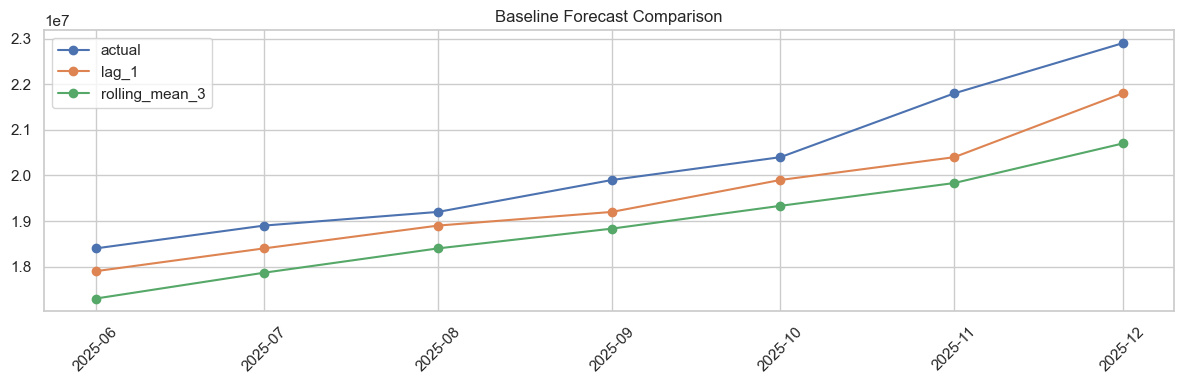

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(test_df[time_col], test_df[target_col], marker="o", label="actual")
plt.plot(test_df[time_col], test_df["lag_1"], marker="o", label="lag_1")
plt.plot(test_df[time_col], test_df["rolling_mean_3"], marker="o", label="rolling_mean_3")
plt.title("Baseline Forecast Comparison")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Notes

- `lag_1` is the simplest monthly baseline.
- `rolling_mean_3` is a slightly smoother baseline.
- Use this notebook as the reference point before adding SARIMAX or other models.
